In [8]:
# ── Cell 1 — imports, path & reload ───────────────────────────────────────────
import sys, os, importlib, warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
sys.path.insert(0, os.path.abspath('../../model'))
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('../.'))

import numpy as np
import matplotlib.pyplot as plt
import xso
from xso.parscans import run_xso_parscan, run_xso_stabilityscan, avg_tail

import cariaco_obs as co
import cariaco_baseline_setups as cbs
import parscan_utils as pu
import parscan_plots as pp
for m in (co, cbs, pu, pp):            # pick up edits without a kernel restart
    importlib.reload(m)

phyto_esd, zoo_esd = cbs.phyto_esd, cbs.zoo_esd
print(f'grid: {len(phyto_esd)} phyto ({phyto_esd[0]:.2g}–{phyto_esd[-1]:.0f} µm), '
      f'{len(zoo_esd)} zoo ({zoo_esd[0]:.2g}–{zoo_esd[-1]:.0f} µm)')

grid: 40 phyto (0.2–200 µm), 40 zoo (2–2000 µm)


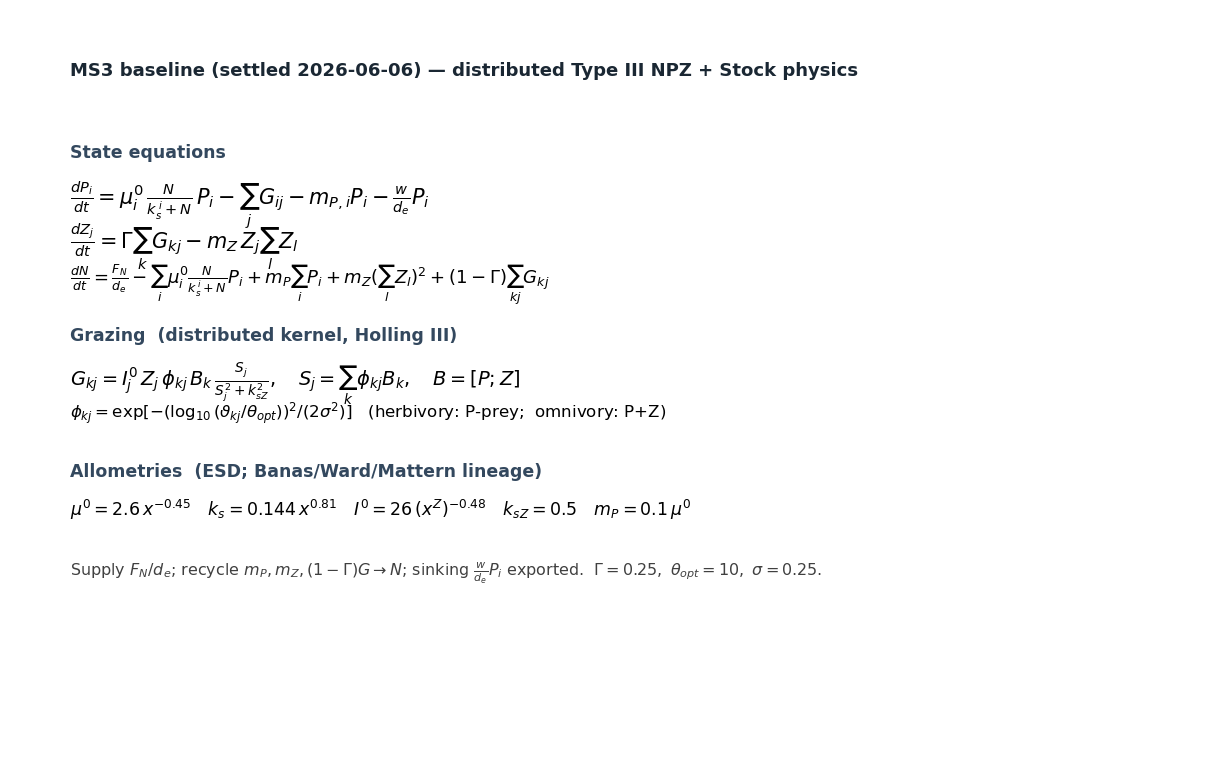

In [2]:
# ── Cell 2 — Fig 0: baseline model equations (distributed Type III) ──────────
eq_blocks = [
    ("State equations", dict(size=12.5, weight='bold', color='#33485e', gap=0.4)),
    (r"$\frac{dP_i}{dt}=\mu^0_i\,\frac{N}{k_s^{\,i}+N}\,P_i-\sum_j G_{ij}-m_{P,i}P_i-\frac{w}{d_e}P_i$", dict(size=15)),
    (r"$\frac{dZ_j}{dt}=\Gamma\sum_k G_{kj}-m_Z\,Z_j\sum_l Z_l$", dict(size=15)),
    (r"$\frac{dN}{dt}=\frac{F_N}{d_e}-\sum_i\mu^0_i\frac{N}{k_s^{\,i}+N}P_i+m_P\sum_i P_i+m_Z(\sum_l Z_l)^2+(1-\Gamma)\sum_{kj}G_{kj}$", dict(size=13)),
    ("Grazing  (distributed kernel, Holling III)", dict(size=12.5, weight='bold', color='#33485e', gap=0.7)),
    (r"$G_{kj}=I^0_j\,Z_j\,\phi_{kj}\,B_k\,\frac{S_j}{S_j^{2}+k_{sZ}^{2}},\quad S_j=\sum_k\phi_{kj}B_k,\quad B=[P;Z]$", dict(size=14)),
    (r"$\phi_{kj}=\exp[-(\log_{10}(\vartheta_{kj}/\theta_{opt}))^2/(2\sigma^2)]$   (herbivory: P-prey;  omnivory: P+Z)", dict(size=12)),
    ("Allometries  (ESD; Banas/Ward/Mattern lineage)", dict(size=12.5, weight='bold', color='#33485e', gap=0.7)),
    (r"$\mu^0=2.6\,x^{-0.45}\quad k_s=0.144\,x^{0.81}\quad I^0=26\,(x^{Z})^{-0.48}\quad k_{sZ}=0.5\quad m_P=0.1\,\mu^0$", dict(size=12.5)),
    (r"Supply $F_N/d_e$; recycle $m_P,m_Z,(1-\Gamma)G\to N$; sinking $\frac{w}{d_e}P_i$ exported.  $\Gamma=0.25,\ \theta_{opt}=10,\ \sigma=0.25$.", dict(size=11.5, color='0.25', gap=0.7)),
]
fig = pp.plot_equation_sheet(eq_blocks,
    title=r"MS3 baseline (settled 2026-06-06) — distributed Type III NPZ + Stock physics")
plt.show()

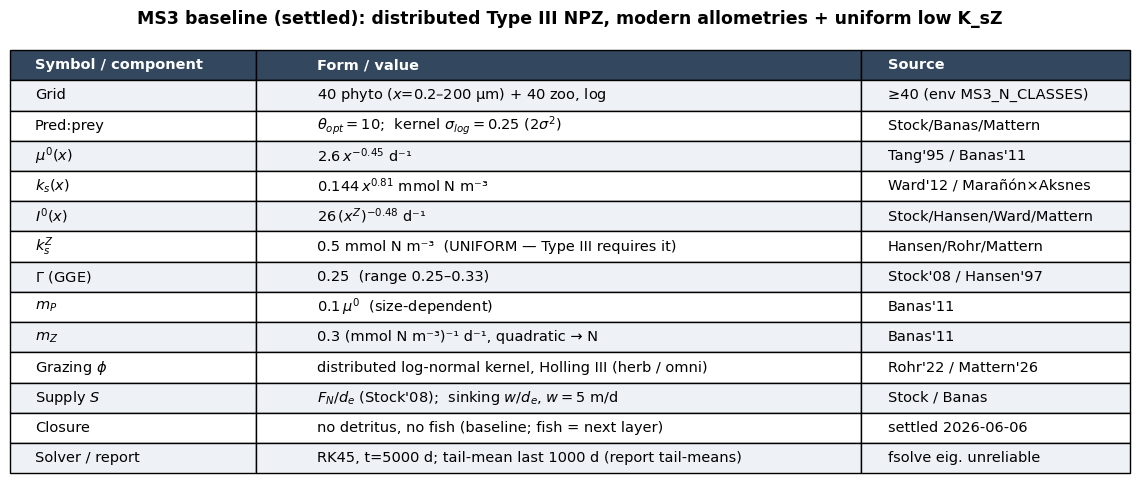

In [3]:
# ── Cell 3 — Fig 1: model structure & parameters (settled construct) ─────────
lo, hi = cbs.phyto_esd[0], cbs.phyto_esd[-1]
rows = [
    ("Grid",            f"{cbs.N_CLASSES} phyto ($x$={lo:.2g}–{hi:.0f} µm) + {cbs.N_CLASSES} zoo, log", "≥40 (env MS3_N_CLASSES)"),
    ("Pred:prey",       r"$\theta_{opt}=10$;  kernel $\sigma_{log}=0.25$ (2$\sigma^2$)",      "Stock/Banas/Mattern"),
    (r"$\mu^0(x)$",     r"$2.6\,x^{-0.45}$ d⁻¹",                                              "Tang'95 / Banas'11"),
    (r"$k_s(x)$",       r"$0.144\,x^{0.81}$ mmol N m⁻³",                                      "Ward'12 / Marañón×Aksnes"),
    (r"$I^0(x)$",       r"$26\,(x^{Z})^{-0.48}$ d⁻¹",                                         "Stock/Hansen/Ward/Mattern"),
    (r"$k_s^{Z}$",      f"{cbs.KSZ_UNIFORM} mmol N m⁻³  (UNIFORM — Type III requires it)",    "Hansen/Rohr/Mattern"),
    (r"$\Gamma$ (GGE)", f"{cbs.GAMMA_VAL}  (range 0.25–0.33)",                                "Stock'08 / Hansen'97"),
    (r"$m_P$",          r"$0.1\,\mu^0$  (size-dependent)",                                    "Banas'11"),
    (r"$m_Z$",          f"{cbs.M_Z_VAL} (mmol N m⁻³)⁻¹ d⁻¹, quadratic → N",                   "Banas'11"),
    (r"Grazing $\phi$", "distributed log-normal kernel, Holling III (herb / omni)",          "Rohr'22 / Mattern'26"),
    (r"Supply $S$",     r"$F_N/d_e$ (Stock'08);  sinking $w/d_e$, $w=5$ m/d",                 "Stock / Banas"),
    ("Closure",         "no detritus, no fish (baseline; fish = next layer)",                "settled 2026-06-06"),
    ("Solver / report", "RK45, t=5000 d; tail-mean last 1000 d (report tail-means)",          "fsolve eig. unreliable"),
]
fig = pp.plot_parameter_table(rows,
    title="MS3 baseline (settled): distributed Type III NPZ, modern allometries + uniform low K_sZ")
plt.show()

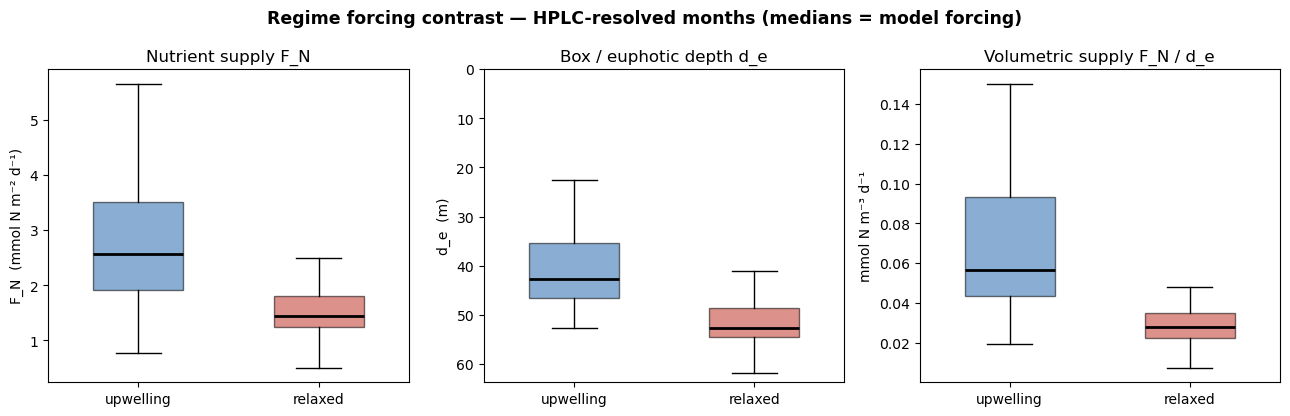

upwelling   n=31   F_N= 2.58   d_e= 42.8   F_N/d_e=0.0603
relaxed     n=58   F_N= 1.45   d_e= 52.7   F_N/d_e=0.0275


In [4]:
# ── Cell 4 — Fig 2: regime forcing (upwelling vs relaxed, HPLC months) ───────
regimes = ('upwelling', 'relaxed')

targets = {}
for r in regimes:
    obs_vec, labels, bin_defs, monthly_df, forcing = co.load_cariaco_targets(
        regime=r, months='hplc', agg='median')
    targets[r] = dict(obs_vec=obs_vec, monthly_df=monthly_df, forcing=forcing)

fig = pp.plot_regime_forcing({r: targets[r]['monthly_df'] for r in regimes},
                             regimes=regimes)
plt.show()

for r in regimes:
    f = targets[r]['forcing']
    print(f"{r:10s}  n={len(targets[r]['monthly_df']):2d}   "
          f"F_N={f['Inflow__FN']:5.2f}   d_e={f['Inflow__de']:5.1f}   "
          f"F_N/d_e={f['Inflow__FN']/f['Inflow__de']:.4f}")

In [5]:
# ── R0 regime diagnostic on the SETTLED construct: distributed Type III, K_sZ=0.5 ─
import importlib, numpy as np
import cariaco_baseline_setups as cbs, cariaco_obs as co, run_baseline_diagnostic as rbd
from parscan_utils import aggregate_model_to_targets, compute_phyto_spectrum_metrics
from cariaco_obs import TARGET_BIN_DEFINITIONS
for m in (cbs, co, rbd):
    importlib.reload(m)

pe, ze = cbs.phyto_esd, cbs.zoo_esd; logpe = np.log10(pe)
pbd = [b for b in TARGET_BIN_DEFINITIONS if b['type'] == 'phyto']
KSZ = 0.5; ksz_arr = np.full(len(ze), KSZ); TAIL = 1000
MODE = 'herb'                              # 'herb' or 'omni'
model, setup = cbs.model_dist_t3, getattr(cbs, f'model_setup_dist_{MODE}_t3_slim')

def mcs(P): a = P > 1e-6; t = P[a].sum(); return 10**np.sum((P[a]/t)*logpe[a]) if t > 0 else np.nan

print(f"distributed Type III, {MODE}, K_sZ={KSZ}, N={len(pe)}")
for r in ('upwelling', 'relaxed'):
    obs_vec, labels, bd, mdf, forc = co.load_cariaco_targets(regime=r, months='hplc', agg='median')
    ov = {'Inflow': {'FN': forc['Inflow__FN'], 'de': forc['Inflow__de']}, 'Grazing': {'KsZ': ksz_arr}}
    st = rbd.extract_state(rbd.run_setup(model, setup, input_vars_override=ov))
    P = st['P']
    if not np.all(np.isfinite(P[:, -1])):
        print(f"  {r:10s}: CRASHED — loosen instability_neg_threshold"); continue
    Pt = np.clip(P[:, -TAIL:].mean(1), 0, None)
    sP = P.sum(0)[-TAIL:]; cv = sP.std()/abs(sP.mean())
    fr = (lambda v: np.array(v)/np.sum(v))(aggregate_model_to_targets({'phyto': Pt}, pe, ze, pbd))
    obs_mcs = 10**compute_phyto_spectrum_metrics(np.array(obs_vec[:len(pbd)]), pbd)['centroid']
    print(f"  {r:10s} F_N={forc['Inflow__FN']:.2f} de={forc['Inflow__de']:.1f} | CV(ΣP)={cv:.3f} | "
          f"model mcs={mcs(Pt):.2f}µm (P/N/M={fr[0]:.2f}/{fr[1]:.2f}/{fr[2]:.2f}) | obs mcs={obs_mcs:.2f}µm")

distributed Type III, herb, K_sZ=0.5, N=40
  upwelling  F_N=2.58 de=42.8 | CV(ΣP)=0.001 | model mcs=1.31µm (P/N/M=0.56/0.44/0.00) | obs mcs=5.50µm
  relaxed    F_N=1.45 de=52.7 | CV(ΣP)=0.001 | model mcs=0.72µm (P/N/M=0.82/0.18/0.00) | obs mcs=2.00µm


upwelling   CV(ΣP)=0.001   model mcs=1.75 µm   obs mcs=4.84 µm
relaxed     CV(ΣP)=0.001   model mcs=0.95 µm   obs mcs=2.01 µm


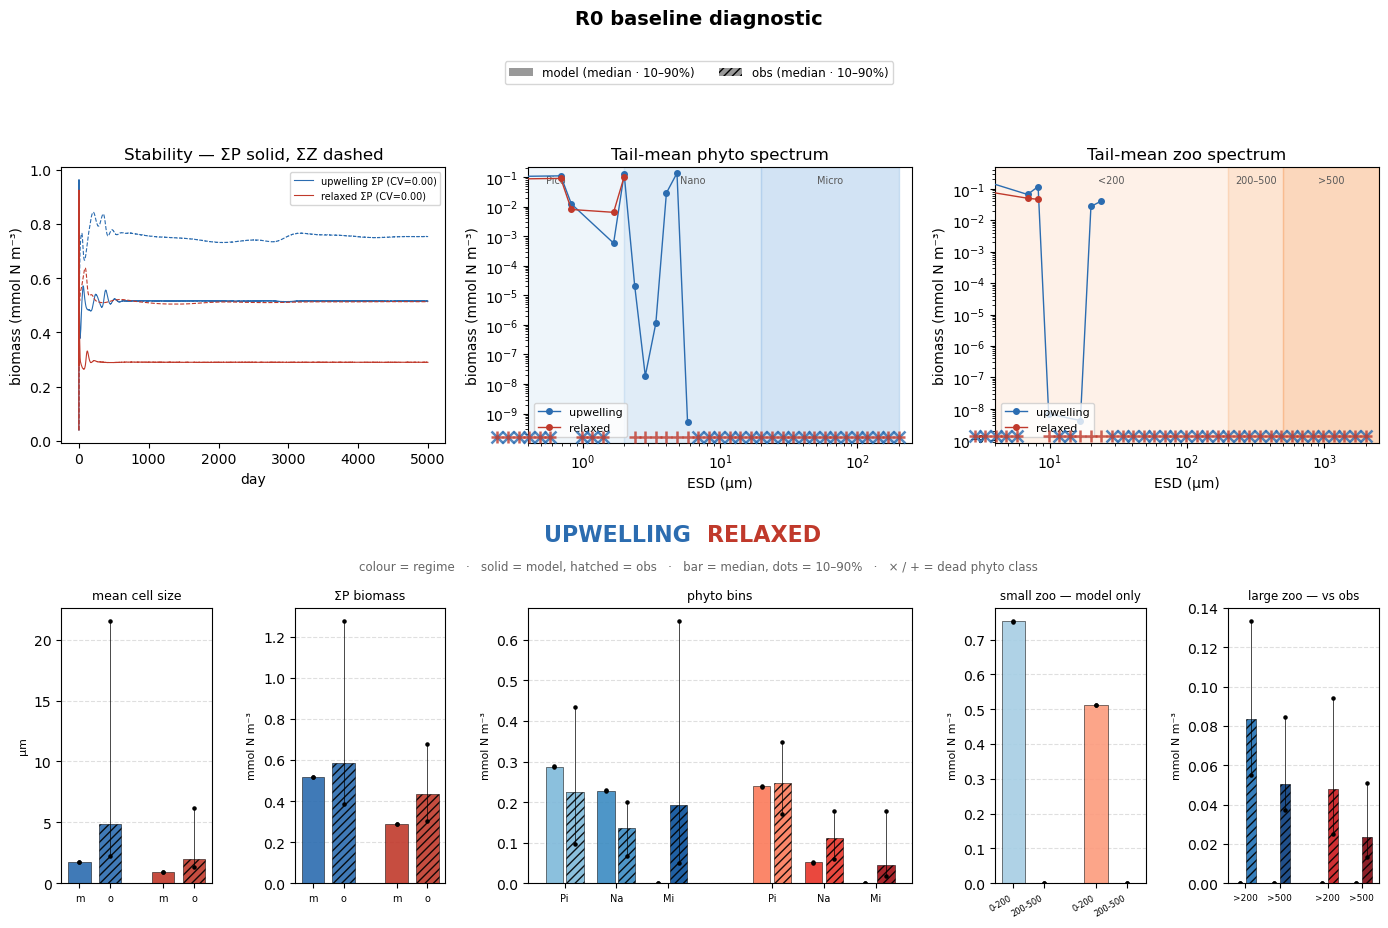

In [6]:
# ── Cell 5 (distributed Type III) — regime diagnostic vs obs (Fig 4) ─────────
import importlib, numpy as np, matplotlib.pyplot as plt
import cariaco_baseline_setups as cbs, cariaco_obs as co, parscan_utils as pu, parscan_plots as pp
for m in (cbs, co, pu, pp):
    importlib.reload(m)

regimes = ('upwelling', 'relaxed')
phyto_esd, zoo_esd = cbs.phyto_esd, cbs.zoo_esd
TAIL = 1000
MODE = 'herb'                                  # 'herb' or 'omni'
model = cbs.model_dist_t3
setup = getattr(cbs, f'model_setup_dist_{MODE}_t3_slim')

targets = {}
for r in regimes:
    obs_vec, labels, bin_defs, monthly_df, forcing = co.load_cariaco_targets(
        regime=r, months='hplc', agg='median')
    targets[r] = dict(forcing=forcing, monthly_df=monthly_df, bin_defs=bin_defs)

model_by_regime, obs_by_regime = {}, {}
for r in regimes:
    out = pu.run_single_point(model, setup, scan_params={},
                              fixed_overrides=targets[r]['forcing'])
    model_by_regime[r] = pu.process_regime_run(out, phyto_esd, zoo_esd,
                                               targets[r]['bin_defs'], tail_len=TAIL)
    obs_by_regime[r]   = pu.process_regime_obs(targets[r]['monthly_df'],
                                               targets[r]['bin_defs'])
    print(f"{r:10s}  CV(ΣP)={model_by_regime[r]['cv']:.3f}   "
          f"model mcs={np.nanmedian(model_by_regime[r]['mcs_tail']):.2f} µm   "
          f"obs mcs={np.nanmedian(obs_by_regime[r]['mcs']):.2f} µm")
fig = pp.plot_regime_diagnostic(model_by_regime, obs_by_regime,
                                phyto_esd, zoo_esd, regimes=regimes)
plt.show()

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_dist_t3' and setup 'model_setup_dist_herb_t3_slim' from 'cariaco_baseline_setups'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_baseline_setups' over 12 points using 8 workers...
1D Scan complete. Time taken: 32.10073 seconds.
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_dist_t3' and setup 'model_setup_dist_omni_t3_slim' from 'cariaco_baseline_setups'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_baseline_setups' over 12 points using 8 workers...


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=75.3 on N = -2.76. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)
/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=158.8 on N = -0.598. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)
/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=178.4 on P[0] = -0.00111. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability

1D Scan complete. Time taken: 28.61719 seconds.


/var/folders/98/6c9k3fxx2hl5k0_928yjt7qw0000gn/T/ipykernel_8670/428077967.py:18: RuntimeWarning: All-NaN slice encountered
  cv.append(proc['cv']); mcs.append(np.nanmedian(proc['mcs_tail']))


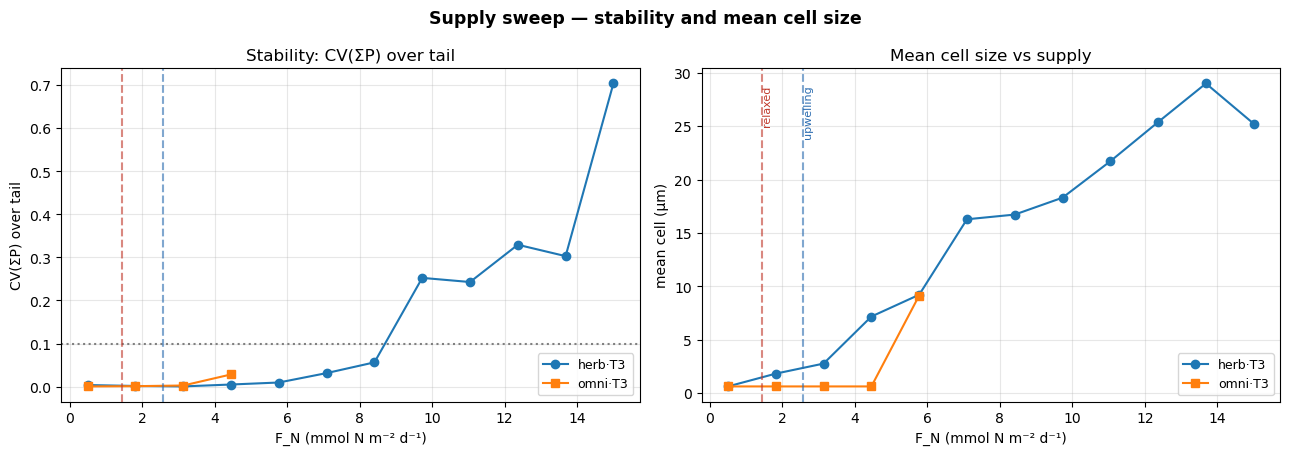

 F_N    CV_herb CV_omni  mcs_herb mcs_omni
 0.50   0.004  0.000     0.63     0.63
 1.82   0.002  0.001     1.83     0.63
 3.14   0.001  0.003     2.77     0.63
 4.45   0.005  0.028     7.17     0.63
 5.77   0.010    nan     9.22     9.14
 7.09   0.031    nan    16.28      nan
 8.41   0.056    nan    16.72      nan
 9.73   0.252    nan    18.30      nan
11.05   0.243    nan    21.72      nan
12.36   0.329    nan    25.38      nan
13.68   0.303    nan    28.99      nan
15.00   0.704    nan    25.22      nan


In [13]:
# ── Cell 6 — supply sweep (herb vs omni, Type III): CV + mean cell size vs F_N ─
fn_values = np.linspace(0.5, 15.0, 12)
DE_SWEEP  = cbs.DE_DEFAULT
variant_setups = {
    'herb·T3': ('model_dist_t3', 'model_setup_dist_herb_t3_slim'),
    'omni·T3': ('model_dist_t3', 'model_setup_dist_omni_t3_slim'),
}
sweep = {}
for label, (mname, sname) in variant_setups.items():
    res = run_xso_parscan(model_file_name='cariaco_baseline_setups',
                          model_name=mname, model_setup_name=sname,
                          param_name='Inflow__FN', param_values=fn_values,
                          processes=8, fixed_overrides={'Inflow__de': DE_SWEEP})
    cv, mcs = [], []
    for k in range(len(fn_values)):
        proc = pu.process_regime_run(res.isel({'Inflow__FN': k}),
                                     phyto_esd, zoo_esd, bin_defs, tail_len=TAIL)
        cv.append(proc['cv']); mcs.append(np.nanmedian(proc['mcs_tail']))
    sweep[label] = {'cv': np.array(cv), 'mean_cell': np.array(mcs)}
regime_fn = {r: targets[r]['forcing']['Inflow__FN'] for r in regimes}
fig = pp.plot_stability_scan(sweep, fn_values, regime_fn=regime_fn,
                             metric_key='cv', metric_label='CV(ΣP) over tail',
                             metric_threshold=0.1)
plt.show()
print(" F_N    CV_herb CV_omni  mcs_herb mcs_omni")
for k, fn in enumerate(fn_values):
    print(f"{fn:5.2f}  {sweep['herb·T3']['cv'][k]:6.3f} {sweep['omni·T3']['cv'][k]:6.3f}  "
          f"{sweep['herb·T3']['mean_cell'][k]:7.2f} {sweep['omni·T3']['mean_cell'][k]:8.2f}")

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_dist_t3' and setup 'model_setup_dist_herb_t3_slim' from 'cariaco_baseline_setups'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_baseline_setups' over 12 points using 8 workers...
1D Scan complete. Time taken: 29.89451 seconds.
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_dist_t3' and setup 'model_setup_dist_herb_t3_slim' from 'cariaco_baseline_setups'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_baseline_setups' over 12 points using 8 workers...
1D Scan complete. Time taken: 24.48928 seconds.
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_dist_t3' and setup 'model_setup_dist_herb_t3_slim' from 'cariaco_baseline_setups'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariac

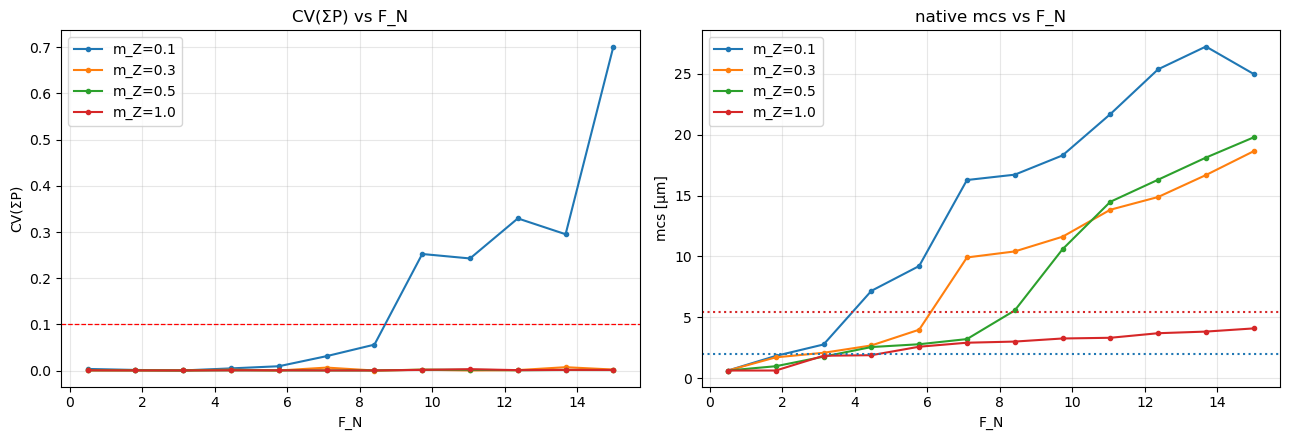

m_Z=0.1: CV 0.001–0.701  mcs 0.63–27.25µm
m_Z=0.3: CV 0.000–0.008  mcs 0.63–18.65µm
m_Z=0.5: CV 0.000–0.002  mcs 0.63–19.79µm
m_Z=1.0: CV 0.000–0.003  mcs 0.63–4.09µm


In [18]:
# ── m_Z (closure strength) damps the high-F_N oscillation — herb·T3 ───────────
fn_values = np.linspace(0.5, 15.0, 12)
m_z_vals  = [0.1, 0.3, 0.5, 1.0]
mz_sweep = {}
for mz in m_z_vals:
    res = run_xso_parscan(model_file_name='cariaco_baseline_setups', model_name='model_dist_t3',
        model_setup_name='model_setup_dist_herb_t3_slim', param_name='Inflow__FN',
        param_values=fn_values, processes=8,
        fixed_overrides={'Inflow__de': cbs.DE_DEFAULT, 'ZooLoss__rate': mz})
    cv, mcs = [], []
    for k in range(len(fn_values)):
        proc = pu.process_regime_run(res.isel({'Inflow__FN': k}), phyto_esd, zoo_esd, bin_defs, tail_len=TAIL)
        cv.append(proc['cv']); mcs.append(np.nanmedian(proc['mcs_tail']))
    mz_sweep[mz] = dict(cv=np.array(cv), mcs=np.array(mcs))

import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for mz in m_z_vals:
    ax[0].plot(fn_values, mz_sweep[mz]['cv'],  'o-', ms=3, label=f'm_Z={mz}')
    ax[1].plot(fn_values, mz_sweep[mz]['mcs'], 'o-', ms=3, label=f'm_Z={mz}')
ax[0].axhline(0.1, color='red', ls='--', lw=.9); ax[0].set(title='CV(ΣP) vs F_N', xlabel='F_N', ylabel='CV(ΣP)')
ax[1].axhline(5.4, color='C3', ls=':'); ax[1].axhline(2.0, color='C0', ls=':')
ax[1].set(title='native mcs vs F_N', xlabel='F_N', ylabel='mcs [µm]')
for a in ax: a.legend(); a.grid(alpha=.3)
plt.tight_layout(); plt.show()
for mz in m_z_vals:
    print(f"m_Z={mz}: CV {np.nanmin(mz_sweep[mz]['cv']):.3f}–{np.nanmax(mz_sweep[mz]['cv']):.3f}  "
          f"mcs {np.nanmin(mz_sweep[mz]['mcs']):.2f}–{np.nanmax(mz_sweep[mz]['mcs']):.2f}µm")

In [14]:
# ── Cell 7 — stability: fsolve + eigenvalues, seeded from IVP tail-mean ───────
# CAVEAT: for this distributed Type III construct the fsolve eigenvalues are UNRELIABLE
# — fsolve lands on spurious foci off the IVP attractor and flags 'unstable' with no
# realized oscillation. Trust CV(ΣP) + the IVP tail-mean (realized state, CV~1e-3).
# The rel.diff below flags when the fsolve point is spurious (large ⇒ ignore the verdict).
from xso.parscans import StabilityAnalysisHook
MODE = 'herb'
model      = cbs.model_dist_t3
slim_setup = getattr(cbs, f'model_setup_dist_{MODE}_t3_slim')
stab_setup = getattr(cbs, f'model_setup_dist_{MODE}_t3_stability')

def tail_mean_seed(out, avg_window=TAIL):
    return {'Nutrient__value_init': float(out['Nutrient__value'].values[-avg_window:].mean()),
            'Phytoplankton__biomass_init': np.maximum(out['Phytoplankton__biomass'].values[:, -avg_window:].mean(axis=1), 1e-9),
            'Zooplankton__biomass_init':   np.maximum(out['Zooplankton__biomass'].values[:, -avg_window:].mean(axis=1), 1e-9)}
def run_stability(model, stab_setup, forcing, seed):
    hook = StabilityAnalysisHook()
    with model:
        out = stab_setup.xsimlab.update_vars(input_vars={**forcing, **seed}).xsimlab.run(hooks=[hook])
    return out, hook.get_results()

stab_by_regime = {}
for r in regimes:
    ivp = pu.run_single_point(model, slim_setup, scan_params={}, fixed_overrides=targets[r]['forcing'])
    out_s, s = run_stability(model, stab_setup, targets[r]['forcing'], tail_mean_seed(ivp))
    P_tail = ivp['Phytoplankton__biomass'].values[:, -TAIL:].mean(axis=1)
    P_ss   = out_s['Phytoplankton__biomass'].isel(time=-1).values
    stab_by_regime[r] = dict(stab=s, P_ss=P_ss, Z_ss=out_s['Zooplankton__biomass'].isel(time=-1).values,
                             P_tail=P_tail, Z_tail=ivp['Zooplankton__biomass'].values[:, -TAIL:].mean(axis=1))
    a = P_tail > 1e-6
    reldiff = np.nanmedian(np.abs(P_ss[a] - P_tail[a]) / P_tail[a])
    print(f"{r:10s}  {s['stability']:9s}  max Re(λ)={s['max_eigenvalue_real']:+.4f}  n_pos={s['n_positive_eigenvalues']}"
          f"  | fsolve-vs-tailmean med rel.diff={reldiff:.2f} (large ⇒ fsolve spurious, trust CV)")

[HOOK] Detected NumericalStabilitySolver - will capture stability results
[HOOK] System stability: UNSTABLE
[HOOK] Max eigenvalue real part: 2.7747e-02
upwelling   unstable   max Re(λ)=+0.0277  n_pos=5  | fsolve-vs-tailmean med rel.diff=0.64 (large ⇒ fsolve spurious, trust CV)
[HOOK] Detected NumericalStabilitySolver - will capture stability results
[HOOK] System stability: UNSTABLE
[HOOK] Max eigenvalue real part: 1.2236e-02
relaxed     unstable   max Re(λ)=+0.0122  n_pos=4  | fsolve-vs-tailmean med rel.diff=0.30 (large ⇒ fsolve spurious, trust CV)


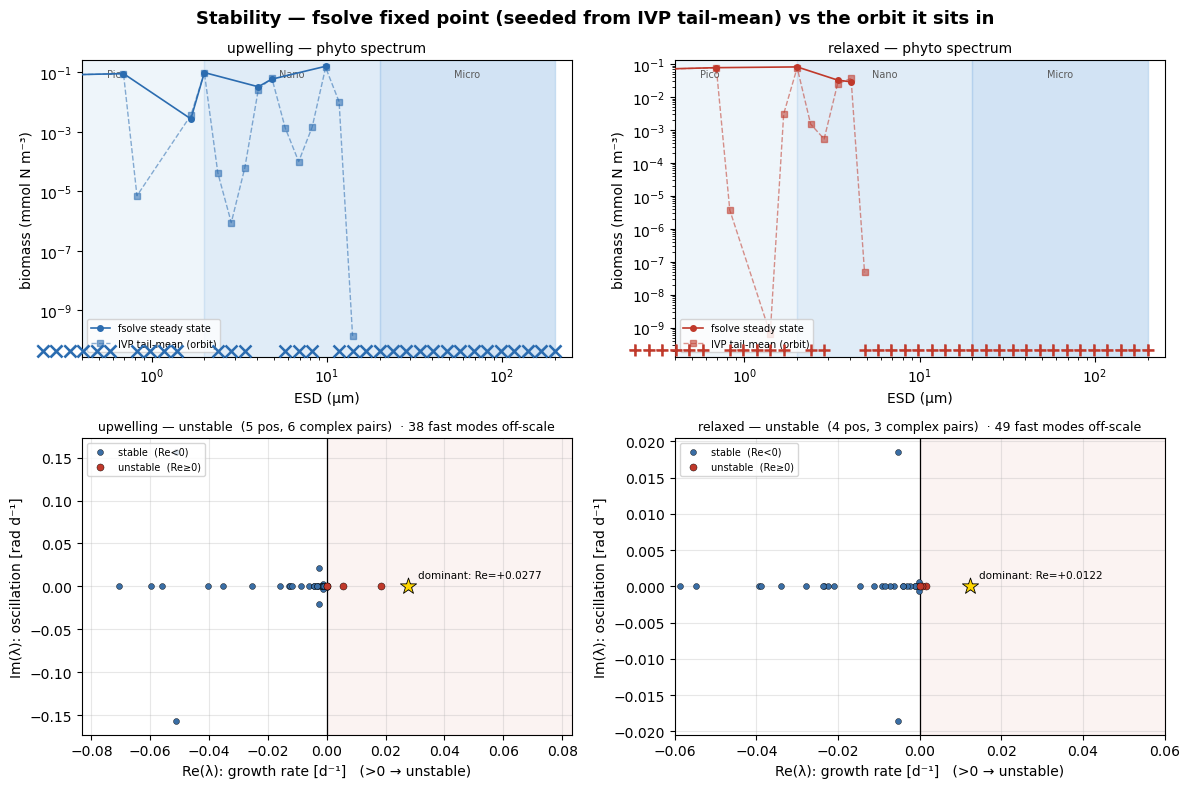

In [15]:
# ── Cell 8 — Fig 6: stability diagnostic (focus vs orbit + eigenvalues) ──────
fig = pp.plot_stability_diagnostic(stab_by_regime, phyto_esd, regimes=regimes)
plt.show()

In [16]:
# ── Cell 9 — consolidated text summary (paste this back to share results) ────
_ = pu.report_regime_diagnostic(
        model_by_regime, obs_by_regime, regimes=regimes,
        forcing_by_regime={r: targets[r]['forcing'] for r in regimes},
        stab_by_regime=stab_by_regime)

=== UPWELLING   (F_N=2.58, d_e=42.8) ===
                       model       obs     m/o
  mean cell um         2.380     4.841    0.49
  sumP mmolN/m3        0.516     0.583    0.88
  Pico frac            0.423     0.406    1.04
  Nano frac            0.577     0.248    2.33
  Micro frac           0.000     0.347    0.00
  zoo gt200            0.000     0.083    0.00
  zoo gt500            0.000     0.051    0.00
  CV(sumP)             0.001
  stability         unstable   max Re(lam)=+0.0277  5 pos, 6 pairs

=== RELAXED   (F_N=1.45, d_e=52.7) ===
                       model       obs     m/o
  mean cell um         1.446     2.013    0.72
  sumP mmolN/m3        0.290     0.436    0.66
  Pico frac            0.639     0.611    1.05
  Nano frac            0.361     0.275    1.31
  Micro frac           0.000     0.114    0.00
  zoo gt200            0.000     0.048    0.00
  zoo gt500            0.000     0.023    0.00
  CV(sumP)             0.001
  stability         unstable   max Re(lam)

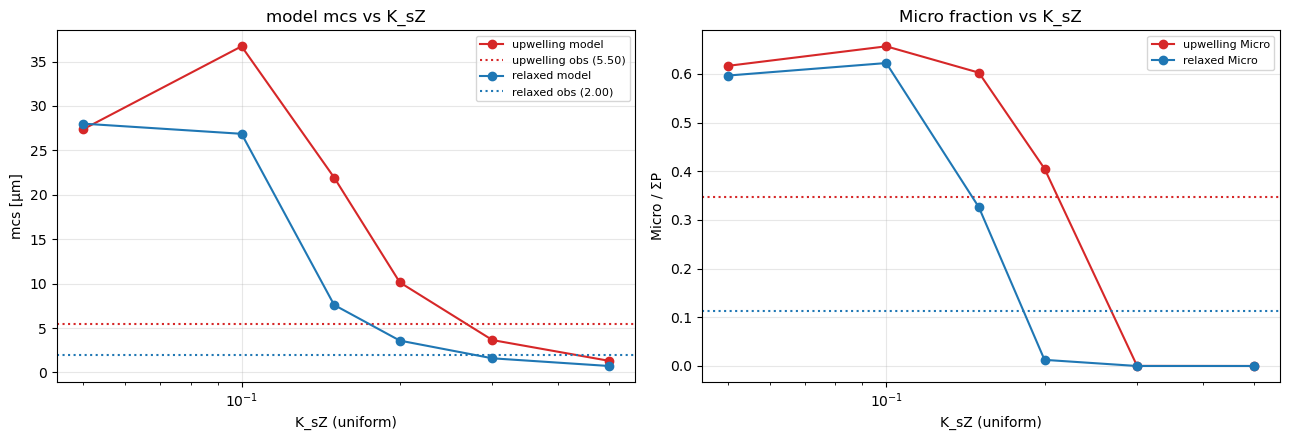


upwelling  (obs mcs=5.50µm  P/N/M=0.41/0.25/0.35  F_N=2.58):
  K_sZ=0.05: mcs=27.38µm  CV=0.009  P/N/M=0.15/0.24/0.62
  K_sZ=0.10: mcs=36.71µm  CV=0.014  P/N/M=0.13/0.22/0.66
  K_sZ=0.15: mcs=21.94µm  CV=0.076  P/N/M=0.13/0.26/0.60
  K_sZ=0.20: mcs=10.13µm  CV=0.025  P/N/M=0.20/0.40/0.41
  K_sZ=0.30: mcs=3.64µm  CV=0.001  P/N/M=0.33/0.67/0.00
  K_sZ=0.50: mcs=1.31µm  CV=0.001  P/N/M=0.56/0.44/0.00

relaxed  (obs mcs=2.00µm  P/N/M=0.61/0.28/0.11  F_N=1.45):
  K_sZ=0.05: mcs=28.01µm  CV=0.020  P/N/M=0.14/0.26/0.60
  K_sZ=0.10: mcs=26.86µm  CV=0.055  P/N/M=0.12/0.25/0.62
  K_sZ=0.15: mcs=7.59µm  CV=0.014  P/N/M=0.24/0.43/0.33
  K_sZ=0.20: mcs=3.58µm  CV=0.002  P/N/M=0.34/0.65/0.01
  K_sZ=0.30: mcs=1.59µm  CV=0.001  P/N/M=0.51/0.49/0.00
  K_sZ=0.50: mcs=0.72µm  CV=0.001  P/N/M=0.82/0.18/0.00


In [7]:
# ── K_sZ obs-fit scan: model vs obs per regime (herb·T3, m_Z=0.3) ────────────
import importlib, numpy as np, matplotlib.pyplot as plt
import cariaco_baseline_setups as cbs, cariaco_obs as co, run_baseline_diagnostic as rbd
from parscan_utils import aggregate_model_to_targets, compute_phyto_spectrum_metrics
from cariaco_obs import TARGET_BIN_DEFINITIONS
for m in (cbs, co, rbd):
    importlib.reload(m)

pe, ze = cbs.phyto_esd, cbs.zoo_esd; logpe = np.log10(pe)
pbd = [b for b in TARGET_BIN_DEFINITIONS if b['type'] == 'phyto']
TAIL = 1000
KSZ_LIST = [0.05, 0.1, 0.15, 0.2, 0.3, 0.5]
MODE = 'herb'
model, setup = cbs.model_dist_t3, getattr(cbs, f'model_setup_dist_{MODE}_t3_slim')

def mcs(P): a = P > 1e-6; t = P[a].sum(); return 10**np.sum((P[a]/t)*logpe[a]) if t > 0 else np.nan

obs = {}
for r in ('upwelling', 'relaxed'):
    ov_vec, *_, forc = co.load_cariaco_targets(regime=r, months='hplc', agg='median')
    pv = np.array(ov_vec[:len(pbd)])
    obs[r] = dict(forcing=forc, mcs=10**compute_phyto_spectrum_metrics(pv, pbd)['centroid'], fr=pv/pv.sum())

res = {r: {k: [] for k in ('mcs', 'cv', 'pico', 'nano', 'micro')} for r in obs}
for r in obs:
    f = obs[r]['forcing']
    for ksz in KSZ_LIST:
        ov = {'Inflow': {'FN': f['Inflow__FN'], 'de': f['Inflow__de']},
              'Grazing': {'KsZ': np.full(len(ze), ksz)}, 'ZooLoss': {'rate': 0.3}}
        st = rbd.extract_state(rbd.run_setup(model, setup, input_vars_override=ov))
        P = st['P']
        if not np.all(np.isfinite(P[:, -1])):
            for k in res[r]: res[r][k].append(np.nan)
            continue
        Pt = np.clip(P[:, -TAIL:].mean(1), 0, None)
        sP = P.sum(0)[-TAIL:]
        fr = (lambda v: np.array(v)/np.sum(v))(aggregate_model_to_targets({'phyto': Pt}, pe, ze, pbd))
        res[r]['mcs'].append(mcs(Pt)); res[r]['cv'].append(sP.std()/abs(sP.mean()))
        res[r]['pico'].append(fr[0]); res[r]['nano'].append(fr[1]); res[r]['micro'].append(fr[2])

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for r, c in [('upwelling', 'C3'), ('relaxed', 'C0')]:
    ax[0].plot(KSZ_LIST, res[r]['mcs'], 'o-', color=c, label=f'{r} model')
    ax[0].axhline(obs[r]['mcs'], color=c, ls=':', label=f'{r} obs ({obs[r]["mcs"]:.2f})')
    ax[1].plot(KSZ_LIST, res[r]['micro'], 'o-', color=c, label=f'{r} Micro')
    ax[1].axhline(obs[r]['fr'][2], color=c, ls=':')
for a, t in zip(ax, ('model mcs vs K_sZ', 'Micro fraction vs K_sZ')):
    a.set(title=t, xlabel='K_sZ (uniform)'); a.set_xscale('log'); a.legend(fontsize=8); a.grid(alpha=.3)
ax[0].set_ylabel('mcs [µm]'); ax[1].set_ylabel('Micro / ΣP')
plt.tight_layout(); plt.show()

for r in obs:
    print(f"\n{r}  (obs mcs={obs[r]['mcs']:.2f}µm  P/N/M={obs[r]['fr'][0]:.2f}/{obs[r]['fr'][1]:.2f}/{obs[r]['fr'][2]:.2f}  "
          f"F_N={obs[r]['forcing']['Inflow__FN']:.2f}):")
    for i, ksz in enumerate(KSZ_LIST):
        print(f"  K_sZ={ksz:.2f}: mcs={res[r]['mcs'][i]:.2f}µm  CV={res[r]['cv'][i]:.3f}  "
              f"P/N/M={res[r]['pico'][i]:.2f}/{res[r]['nano'][i]:.2f}/{res[r]['micro'][i]:.2f}")

In [9]:
# ── Stability check at the fit operating point: K_sZ=0.25, m_Z=0.3 ───────────
import importlib, numpy as np
import cariaco_baseline_setups as cbs, cariaco_obs as co, run_baseline_diagnostic as rbd
for m in (cbs, co, rbd):
    importlib.reload(m)
from xso.parscans import run_xso_parscan
import xso

pe, ze = cbs.phyto_esd, cbs.zoo_esd; logpe = np.log10(pe)
KSZ, MZ = 0.25, 0.3
ksz_arr = np.full(len(ze), KSZ)
def mcs(P): a = P > 1e-6; t = P[a].sum(); return 10**np.sum((P[a]/t)*logpe[a]) if t > 0 else np.nan

# A) full F_N range at the fit K_sZ — does low K_sZ reintroduce high-F_N oscillation?
fn_values = np.linspace(0.5, 15, 15)
res = run_xso_parscan(model_file_name='cariaco_baseline_setups', model_name='model_dist_t3',
    model_setup_name='model_setup_dist_herb_t3_slim', param_name='Inflow__FN',
    param_values=fn_values, processes=8,
    fixed_overrides={'Inflow__de': cbs.DE_DEFAULT, 'Grazing__KsZ': ksz_arr, 'ZooLoss__rate': MZ})
print(f"F_N sweep @ K_sZ={KSZ}, m_Z={MZ}:")
cvs = []
for k in range(len(fn_values)):
    Pda = res.Phytoplankton__biomass.isel({'Inflow__FN': k})
    Pt = np.clip(Pda.isel(time=slice(-1000, None)).mean('time').values, 0, None)
    sP = Pda.sum('phyto').isel(time=slice(-1000, None)).values
    cv = sP.std()/abs(sP.mean()) if (np.all(np.isfinite(Pt)) and sP.mean() != 0) else np.nan
    cvs.append(cv)
    print(f"  F_N={fn_values[k]:5.2f}:  CV={cv:.3f}   mcs={mcs(Pt):.2f}µm")
print(f"  → CV range {np.nanmin(cvs):.3f}–{np.nanmax(cvs):.3f}")

# B) long-run (15000 d) settling at the two regime operating points
long_setup = xso.setup(solver='solve_ivp', model=cbs.model_dist_t3, time=np.arange(0, 15000, 1),
    input_vars=cbs.make_dist_input_vars(cbs.phiPZ_herb), solver_kwargs=cbs.IVP_SOLVER_KWARGS)
print("\nLong-run (15000 d) settling at regime operating points:")
for r in ('upwelling', 'relaxed'):
    *_, f = co.load_cariaco_targets(regime=r, months='hplc', agg='median')
    ov = {'Inflow': {'FN': f['Inflow__FN'], 'de': f['Inflow__de']},
          'Grazing': {'KsZ': ksz_arr}, 'ZooLoss': {'rate': MZ}}
    st = rbd.extract_state(rbd.run_setup(cbs.model_dist_t3, long_setup, input_vars_override=ov))
    sP = st['P'].sum(0)
    cv_end1 = sP[-1000:].std()/abs(sP[-1000:].mean())
    cv_end2 = sP[-2000:].std()/abs(sP[-2000:].mean())
    cv_mid  = sP[7000:9000].std()/abs(sP[7000:9000].mean())
    print(f"  {r:10s} F_N={f['Inflow__FN']:.2f}:  CV mid={cv_mid:.4f}  last2000={cv_end2:.4f}  "
          f"last1000={cv_end1:.4f}  mcs={mcs(st['P'][:, -1000:].mean(1)):.2f}µm")

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_dist_t3' and setup 'model_setup_dist_herb_t3_slim' from 'cariaco_baseline_setups'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_baseline_setups' over 15 points using 8 workers...


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=3957 on P[8] = -0.00273. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)
/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=3818 on P[0] = -0.00597. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)
/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=4056 on P[20] = -0.00105. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'i

1D Scan complete. Time taken: 29.15804 seconds.
F_N sweep @ K_sZ=0.25, m_Z=0.3:
  F_N= 0.50:  CV=0.001   mcs=0.62µm
  F_N= 1.54:  CV=0.004   mcs=2.37µm
  F_N= 2.57:  CV=0.009   mcs=5.61µm
  F_N= 3.61:  CV=0.027   mcs=10.80µm
  F_N= 4.64:  CV=0.023   mcs=16.47µm
  F_N= 5.68:  CV=0.331   mcs=20.81µm
  F_N= 6.71:  CV=0.372   mcs=26.61µm
  F_N= 7.75:  CV=0.317   mcs=33.98µm
  F_N= 8.79:  CV=nan   mcs=nanµm
  F_N= 9.82:  CV=0.865   mcs=36.22µm
  F_N=10.86:  CV=nan   mcs=nanµm
  F_N=11.89:  CV=0.649   mcs=43.45µm
  F_N=12.93:  CV=4.100   mcs=56.11µm
  F_N=13.96:  CV=0.346   mcs=77.57µm
  F_N=15.00:  CV=0.403   mcs=68.74µm
  → CV range 0.001–4.100

Long-run (15000 d) settling at regime operating points:
  upwelling  F_N=2.58:  CV mid=0.0016  last2000=0.0009  last1000=0.0008  mcs=5.67µm
  relaxed    F_N=1.45:  CV mid=0.0006  last2000=0.0006  last1000=0.0006  mcs=2.16µm


In [10]:
# ── m_Z sweep at the fit K_sZ=0.25: stability across F_N vs size cost ─────────
import numpy as np
from xso.parscans import run_xso_parscan
KSZ = 0.25; m_z_vals = [0.3, 0.5, 0.7, 1.0]
fn_values = np.linspace(0.5, 15, 12)
ksz_arr = np.full(len(ze), KSZ)
print(f"m_Z sweep at K_sZ={KSZ} (mcs@F_N≈2.6 = observed upwelling target ~5.5µm):")
for mz in m_z_vals:
    res = run_xso_parscan(model_file_name='cariaco_baseline_setups', model_name='model_dist_t3',
        model_setup_name='model_setup_dist_herb_t3_slim', param_name='Inflow__FN',
        param_values=fn_values, processes=8,
        fixed_overrides={'Inflow__de': cbs.DE_DEFAULT, 'Grazing__KsZ': ksz_arr, 'ZooLoss__rate': mz})
    cvs, mcs_obs = [], np.nan
    for k in range(len(fn_values)):
        Pda = res.Phytoplankton__biomass.isel({'Inflow__FN': k})
        Pt = np.clip(Pda.isel(time=slice(-1000, None)).mean('time').values, 0, None)
        sP = Pda.sum('phyto').isel(time=slice(-1000, None)).values
        cvs.append(sP.std()/abs(sP.mean()) if (np.all(np.isfinite(Pt)) and sP.mean() != 0) else np.nan)
        if abs(fn_values[k] - 2.57) < 0.6:
            mcs_obs = mcs(Pt)
    print(f"  m_Z={mz}: max CV={np.nanmax(cvs):.2f}  stable(CV<0.1)={int(np.sum(np.array(cvs)<0.1))}/{len(fn_values)}"
          f"  mcs@F_N≈2.6={mcs_obs:.2f}µm")

m_Z sweep at K_sZ=0.25 (mcs@F_N≈2.6 = observed upwelling target ~5.5µm):
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_dist_t3' and setup 'model_setup_dist_herb_t3_slim' from 'cariaco_baseline_setups'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_baseline_setups' over 12 points using 8 workers...


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=3905 on P[21] = -0.542 (plus 1 other violating entries). Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


1D Scan complete. Time taken: 26.00864 seconds.
  m_Z=0.3: max CV=0.75  stable(CV<0.1)=4/12  mcs@F_N≈2.6=8.43µm
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_dist_t3' and setup 'model_setup_dist_herb_t3_slim' from 'cariaco_baseline_setups'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_baseline_setups' over 12 points using 8 workers...
1D Scan complete. Time taken: 20.65845 seconds.
  m_Z=0.5: max CV=0.43  stable(CV<0.1)=7/12  mcs@F_N≈2.6=5.43µm
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_dist_t3' and setup 'model_setup_dist_herb_t3_slim' from 'cariaco_baseline_setups'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_baseline_setups' over 12 points using 8 workers...
1D Scan complete. Time taken: 21.0192 seconds.
  m_Z=0.7: max CV=0.09  stable(CV<0.1)=12/12  mcs@F_N≈2.6=4.37µm
--- Starting Parallel Scan

/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=165.3 on P[9] = -0.001. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)
/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=194.6 on P[9] = -0.00144. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


1D Scan complete. Time taken: 21.50103 seconds.
  m_Z=1.0: max CV=0.01  stable(CV<0.1)=10/12  mcs@F_N≈2.6=3.46µm


In [11]:
# ── OPTIONAL: does a single full-range-stable obs-fit exist? (m_Z=0.7, lower K_sZ) ─
import numpy as np
from xso.parscans import run_xso_parscan
MZ = 0.7
print(f"obs-fit K_sZ at m_Z={MZ} (targets: upwelling 5.5, relaxed 2.0 µm):")
for r in ('upwelling', 'relaxed'):
    *_, f = co.load_cariaco_targets(regime=r, months='hplc', agg='median')
    line = f"  {r:10s}: "
    for ksz in [0.10, 0.15, 0.20, 0.25]:
        ov = {'Inflow': {'FN': f['Inflow__FN'], 'de': f['Inflow__de']},
              'Grazing': {'KsZ': np.full(len(ze), ksz)}, 'ZooLoss': {'rate': MZ}}
        st = rbd.extract_state(rbd.run_setup(cbs.model_dist_t3, cbs.model_setup_dist_herb_t3_slim, input_vars_override=ov))
        line += f"K_sZ={ksz}→{mcs(np.clip(st['P'][:, -1000:].mean(1), 0, None)):.1f}µm  "
    print(line)
# stability across F_N at the candidate that fits upwelling
KSZ_C = 0.15
fn_values = np.linspace(0.5, 15, 12)
res = run_xso_parscan(model_file_name='cariaco_baseline_setups', model_name='model_dist_t3',
    model_setup_name='model_setup_dist_herb_t3_slim', param_name='Inflow__FN', param_values=fn_values,
    processes=8, fixed_overrides={'Inflow__de': cbs.DE_DEFAULT, 'Grazing__KsZ': np.full(len(ze), KSZ_C), 'ZooLoss__rate': MZ})
cvs = [(lambda P, sP: sP.std()/abs(sP.mean()) if (np.all(np.isfinite(P)) and sP.mean() != 0) else np.nan)(
        np.clip(res.Phytoplankton__biomass.isel({'Inflow__FN': k}).isel(time=slice(-1000, None)).mean('time').values, 0, None),
        res.Phytoplankton__biomass.isel({'Inflow__FN': k}).sum('phyto').isel(time=slice(-1000, None)).values)
       for k in range(len(fn_values))]
print(f"\nfull-F_N stability at K_sZ={KSZ_C}, m_Z={MZ}: max CV={np.nanmax(cvs):.3f}  stable={int(np.sum(np.array(cvs)<0.1))}/12")

obs-fit K_sZ at m_Z=0.7 (targets: upwelling 5.5, relaxed 2.0 µm):
  upwelling : K_sZ=0.1→15.6µm  K_sZ=0.15→11.0µm  K_sZ=0.2→5.2µm  K_sZ=0.25→3.2µm  
  relaxed   : K_sZ=0.1→11.1µm  K_sZ=0.15→4.0µm  K_sZ=0.2→2.1µm  K_sZ=0.25→1.4µm  
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_dist_t3' and setup 'model_setup_dist_herb_t3_slim' from 'cariaco_baseline_setups'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_baseline_setups' over 12 points using 8 workers...


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=2820 on P[20] = -0.00106. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


1D Scan complete. Time taken: 22.31318 seconds.

full-F_N stability at K_sZ=0.15, m_Z=0.7: max CV=0.738  stable=8/12


In [ ]:
# ── Is the bloom-range instability numerical/small-class-rate, or genuine? ────
import importlib, numpy as np
import cariaco_baseline_setups as cbs, cariaco_obs as co, run_baseline_diagnostic as rbd
for m in (cbs, co, rbd):
    importlib.reload(m)
import xso

pe, ze = cbs.phyto_esd, cbs.zoo_esd
KSZ, MZ, FN_HI, DE = 0.25, 0.3, 8.0, cbs.DE_DEFAULT
ksz_arr = np.full(len(ze), KSZ)
NOEV = {'instability_neg_threshold': float('-inf')}     # don't terminate — measure CV
def CV(P): sP = P.sum(0)[-2000:]; return sP.std()/abs(sP.mean()) if sP.mean() != 0 else np.nan
def mkset(skw):
    return xso.setup(solver='solve_ivp', model=cbs.model_dist_t3, time=np.arange(0, 8000, 1),
                     input_vars=cbs.make_dist_input_vars(cbs.phiPZ_herb), solver_kwargs=skw)
base_ov = {'Inflow': {'FN': FN_HI, 'de': DE}, 'Grazing': {'KsZ': ksz_arr}, 'ZooLoss': {'rate': MZ}}
print(f"High-F_N cell: F_N={FN_HI}, K_sZ={KSZ}, m_Z={MZ}\n")

# TEST 1 — solver tolerance: does the oscillation survive arbitrarily tight integration?
print("TEST 1 — tolerance (CV should be ~unchanged if dynamical, →0 if numerical):")
for tag, skw in [('RK45 default', {'method': 'RK45', 'atol': 1e-6, 'rtol': 1e-4, **NOEV}),
                 ('RK45 tight',   {'method': 'RK45', 'atol': 1e-10, 'rtol': 1e-8, 'max_step': 1.0, **NOEV}),
                 ('LSODA stiff',  {'method': 'LSODA', 'atol': 1e-9, 'rtol': 1e-7, **NOEV})]:
    st = rbd.extract_state(rbd.run_setup(cbs.model_dist_t3, mkset(skw), input_vars_override=base_ov))
    print(f"  {tag:14s}: CV(ΣP)={CV(st['P']):.3f}  finite={np.all(np.isfinite(st['P'][:, -1]))}")

# TEST 2 — cap the giant small-class rates (is it the 0.2µm fast classes?)
print("\nTEST 2 — cap μ_max and I_max at their 0.5µm values (CV unchanged ⇒ not the small classes):")
mu_cap   = np.minimum(2.6 * pe**-0.45, 2.6 * 0.5**-0.45)
imax_cap = np.minimum(26 * ze**-0.48, 26 * (0.5*10)**-0.48)
for tag, extra in [('uncapped', {}),
                   ('μ,I capped', {'Growth': {'mu_max': mu_cap}, 'Grazing': {'KsZ': ksz_arr, 'Imax': imax_cap}})]:
    ov = {**base_ov, **extra}
    st = rbd.extract_state(rbd.run_setup(cbs.model_dist_t3, mkset({'method': 'RK45', 'atol': 1e-6, 'rtol': 1e-4, **NOEV}), input_vars_override=ov))
    print(f"  {tag:12s}: CV(ΣP)={CV(st['P']):.3f}")

In [13]:
# TEST 2 — cap the giant small-class rates (is it the 0.2µm fast classes?)
print("\nTEST 2 — cap μ_max and I_max at their 0.5µm values (CV unchanged ⇒ not the small classes):")
mu_cap   = np.minimum(2.6 * pe**-0.45, 2.6 * 0.5**-0.45)
imax_cap = np.minimum(26 * ze**-0.48, 26 * (0.5*10)**-0.48)
for tag, extra in [('uncapped', {}),
                   ('μ,I capped', {'Growth': {'mu_max': mu_cap}, 'Grazing': {'KsZ': ksz_arr, 'Imax': imax_cap}})]:
    ov = {**base_ov, **extra}
    st = rbd.extract_state(rbd.run_setup(cbs.model_dist_t3, mkset({'method': 'RK45', 'atol': 1e-6, 'rtol': 1e-4, **NOEV}), input_vars_override=ov))
    print(f"  {tag:12s}: CV(ΣP)={CV(st['P']):.3f}")


TEST 2 — cap μ_max and I_max at their 0.5µm values (CV unchanged ⇒ not the small classes):


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=5087 on P[0] = 1.67e+50 (plus 1 other violating entries). Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


  uncapped    : CV(ΣP)=nan
  μ,I capped  : CV(ΣP)=0.541


In [14]:
# ── Bloom instability: numerical vs genuine, and small-class-rate attribution ──
import importlib, numpy as np
import cariaco_baseline_setups as cbs, run_baseline_diagnostic as rbd
for m in (cbs, rbd): importlib.reload(m)
import xso
pe, ze = cbs.phyto_esd, cbs.zoo_esd
KSZ, MZ, FN_HI, DE = 0.25, 0.3, 8.0, cbs.DE_DEFAULT
ksz_arr = np.full(len(ze), KSZ)
NOEV = {'instability_neg_threshold': float('-inf'), 'instability_pos_threshold': 1e60}
def CV(P): sP = P.sum(0)[-2000:]; return sP.std()/abs(sP.mean()) if np.isfinite(sP).all() and sP.mean() != 0 else np.nan
def mkset(skw): return xso.setup(solver='solve_ivp', model=cbs.model_dist_t3, time=np.arange(0, 8000, 1),
                                 input_vars=cbs.make_dist_input_vars(cbs.phiPZ_herb), solver_kwargs=skw)
base_ov = {'Inflow': {'FN': FN_HI, 'de': DE}, 'Grazing': {'KsZ': ksz_arr}, 'ZooLoss': {'rate': MZ}}
TIGHT = {'method': 'RK45', 'atol': 1e-10, 'rtol': 1e-8, 'max_step': 1.0, **NOEV}

# TEST 2 — cap the giant small-class rates (run at tight tol so it stays bounded)
print("TEST 2 — cap μ_max,I_max at 0.5µm values (CV ~unchanged ⇒ not the small classes):")
mu_cap   = np.minimum(2.6 * pe**-0.45, 2.6 * 0.5**-0.45)
imax_cap = np.minimum(26 * ze**-0.48, 26 * (5.0)**-0.48)
for tag, extra in [('uncapped', {}),
                   ('μ,I capped', {'Growth': {'mu_max': mu_cap}, 'Grazing': {'KsZ': ksz_arr, 'Imax': imax_cap}})]:
    st = rbd.extract_state(rbd.run_setup(cbs.model_dist_t3, mkset(TIGHT), input_vars_override={**base_ov, **extra}))
    print(f"  {tag:12s}: CV(ΣP)={CV(st['P']):.3f}")

TEST 2 — cap μ_max,I_max at 0.5µm values (CV ~unchanged ⇒ not the small classes):
  uncapped    : CV(ΣP)=0.677
  μ,I capped  : CV(ΣP)=0.624


In [16]:
# ── Resolution check on the bloom limit cycle (paradox of enrichment) ────────
import os, importlib, numpy as np
import run_baseline_diagnostic as rbd
import xso

FN_HI, KSZ, MZ = 8.0, 0.25, 0.3
TIGHT = {'method': 'RK45', 'atol': 1e-9, 'rtol': 1e-7, 'max_step': 2.0,
         'instability_neg_threshold': float('-inf'), 'instability_pos_threshold': 1e60}

print(f"Bloom limit cycle vs resolution  (F_N={FN_HI}, K_sZ={KSZ}, m_Z={MZ}):")
for N in [120, 40, 80]:
    os.environ['MS3_N_CLASSES'] = str(N)
    import cariaco_baseline_setups as cbs
    importlib.reload(cbs)
    ze = cbs.zoo_esd; DE = cbs.DE_DEFAULT
    setup = xso.setup(solver='solve_ivp', model=cbs.model_dist_t3, time=np.arange(0, 8000, 1),
                      input_vars=cbs.make_dist_input_vars(cbs.phiPZ_herb), solver_kwargs=TIGHT)
    ov = {'Inflow': {'FN': FN_HI, 'de': DE},
          'Grazing': {'KsZ': np.full(len(ze), KSZ)}, 'ZooLoss': {'rate': MZ}}
    st = rbd.extract_state(rbd.run_setup(cbs.model_dist_t3, setup, input_vars_override=ov))
    sP = st['P'].sum(0)
    finite = np.isfinite(st['P'][:, -1]).all()
    cv = sP[-2000:].std()/abs(sP[-2000:].mean()) if finite else np.nan
    tail = sP[-4000:] - sP[-4000:].mean()                       # detrended tail for FFT period
    pw = np.abs(np.fft.rfft(tail))**2
    fr = np.fft.rfftfreq(len(tail), d=1.0)
    period = 1.0/fr[1 + np.argmax(pw[1:])] if (finite and len(pw) > 2) else np.nan
    print(f"  N={N:3d}:  CV(ΣP)={cv:.3f}   period≈{period:5.0f} d   finite={finite}")
os.environ['MS3_N_CLASSES'] = '40'      # restore default
print("(N restored to 40)")

Bloom limit cycle vs resolution  (F_N=8.0, K_sZ=0.25, m_Z=0.3):
  N=120:  CV(ΣP)=0.441   period≈  114 d   finite=True
  N= 40:  CV(ΣP)=0.234   period≈   95 d   finite=True
  N= 80:  CV(ΣP)=0.403   period≈   93 d   finite=True
(N restored to 40)


In [18]:
# ── Temperature test: Cloern Q10 scaling of growth & grazing, per regime ─────
import importlib, numpy as np
import cariaco_baseline_setups as cbs, cariaco_obs as co, run_baseline_diagnostic as rbd
from parscan_utils import aggregate_model_to_targets, compute_phyto_spectrum_metrics
from cariaco_obs import TARGET_BIN_DEFINITIONS
for m in (cbs, co, rbd):
    importlib.reload(m)

pe, ze = cbs.phyto_esd, cbs.zoo_esd; logpe = np.log10(pe)
pbd = [b for b in TARGET_BIN_DEFINITIONS if b['type'] == 'phyto']
KSZ, MZ = 0.25, 0.3; ksz_arr = np.full(len(ze), KSZ)
Q10_GROW, Q10_GRAZE, T_REF = 1.62, 2.48, 20.0          # Cloern 2018
mu0, imax0 = 2.6 * pe**-0.45, 26 * ze**-0.48
def mcs(P): a = P > 1e-6; t = P[a].sum(); return 10**np.sum((P[a]/t)*logpe[a]) if t > 0 else np.nan

for r in ('upwelling', 'relaxed'):
    obs_vec, _, _, mdf, forc = co.load_cariaco_targets(regime=r, months='hplc', agg='median')
    T = float(mdf['Temp_C'].median()) if 'Temp_C' in mdf else np.nan
    fg, fz = Q10_GROW**((T-T_REF)/10), Q10_GRAZE**((T-T_REF)/10)
    pv = np.array(obs_vec[:len(pbd)]); obs_fr = pv/pv.sum()
    obs_mcs = 10**compute_phyto_spectrum_metrics(pv, pbd)['centroid']
    for tag, extra in [('no-temp (R0)', {}),
                       (f'+temp(T={T:.1f},×g{fg:.2f}/z{fz:.2f})',
                        {'Growth': {'mu_max': mu0*fg}, 'Grazing': {'KsZ': ksz_arr, 'Imax': imax0*fz}})]:
        ov = {'Inflow': {'FN': forc['Inflow__FN'], 'de': forc['Inflow__de']},
              'Grazing': {'KsZ': ksz_arr}, 'ZooLoss': {'rate': MZ}, **extra}
        st = rbd.extract_state(rbd.run_setup(cbs.model_dist_t3, cbs.model_setup_dist_herb_t3_slim, input_vars_override=ov))
        Pt = np.clip(st['P'][:, -1000:].mean(1), 0, None)
        fr = (lambda v: np.array(v)/np.sum(v))(aggregate_model_to_targets({'phyto': Pt}, pe, ze, pbd))
        print(f"{r:10s} {tag:28s}: mcs={mcs(Pt):.2f}µm  P/N/M={fr[0]:.2f}/{fr[1]:.2f}/{fr[2]:.2f}")
    print(f"{r:10s} {'OBS':28s}: mcs={obs_mcs:.2f}µm  P/N/M={obs_fr[0]:.2f}/{obs_fr[1]:.2f}/{obs_fr[2]:.2f}\n")

upwelling  no-temp (R0)                : mcs=5.59µm  P/N/M=0.27/0.39/0.34
upwelling  +temp(T=23.0,×g1.16/z1.31)  : mcs=7.65µm  P/N/M=0.24/0.40/0.36
upwelling  OBS                         : mcs=5.50µm  P/N/M=0.41/0.25/0.35

relaxed    no-temp (R0)                : mcs=2.20µm  P/N/M=0.41/0.59/0.00
relaxed    +temp(T=25.4,×g1.30/z1.64)  : mcs=3.43µm  P/N/M=0.34/0.66/0.00
relaxed    OBS                         : mcs=2.00µm  P/N/M=0.61/0.28/0.11



In [20]:
# ── K_sZ re-fit with temperature (Cloern) ON — R0 = model_dist_t3_T ──────────
import importlib, numpy as np
import cariaco_baseline_setups as cbs, cariaco_obs as co, run_baseline_diagnostic as rbd
from parscan_utils import aggregate_model_to_targets, compute_phyto_spectrum_metrics
from cariaco_obs import TARGET_BIN_DEFINITIONS
for m in (cbs, co, rbd):
    importlib.reload(m)

pe, ze = cbs.phyto_esd, cbs.zoo_esd; logpe = np.log10(pe)
pbd = [b for b in TARGET_BIN_DEFINITIONS if b['type'] == 'phyto']
MZ = 0.3
KSZ_LIST = [0.2, 0.25, 0.3, 0.4, 0.5, 0.6]
def mcs(P): a = P > 1e-6; t = P[a].sum(); return 10**np.sum((P[a]/t)*logpe[a]) if t > 0 else np.nan

for r in ('upwelling', 'relaxed'):
    obs_vec, _, _, mdf, forc = co.load_cariaco_targets(
        regime=r, months='hplc', agg='median', include_temperature=True)
    T = forc['Temperature__value']
    pv = np.array(obs_vec[:len(pbd)])
    obs_m = 10**compute_phyto_spectrum_metrics(pv, pbd)['centroid']; obs_fr = pv/pv.sum()
    print(f"\n{r}  T={T:.1f}°C  F_N={forc['Inflow__FN']:.2f}  "
          f"obs mcs={obs_m:.2f}µm  P/N/M={obs_fr[0]:.2f}/{obs_fr[1]:.2f}/{obs_fr[2]:.2f}")
    for ksz in KSZ_LIST:
        ov = {'Inflow': {'FN': forc['Inflow__FN'], 'de': forc['Inflow__de']},
              'Temperature': {'value': T},
              'Grazing': {'KsZ': np.full(len(ze), ksz)}, 'ZooLoss': {'rate': MZ}}
        st = rbd.extract_state(rbd.run_setup(cbs.model_dist_t3_T,
                                             cbs.model_setup_dist_herb_t3_T_slim,
                                             input_vars_override=ov))
        Pt = np.clip(st['P'][:, -1000:].mean(1), 0, None)
        sP = st['P'].sum(0)[-1000:]
        fr = (lambda v: np.array(v)/np.sum(v))(aggregate_model_to_targets({'phyto': Pt}, pe, ze, pbd))
        print(f"  K_sZ={ksz:.2f}: mcs={mcs(Pt):.2f}µm  CV={sP.std()/abs(sP.mean()):.3f}  "
              f"P/N/M={fr[0]:.2f}/{fr[1]:.2f}/{fr[2]:.2f}")

ImportError: cannot import name 'ConstantTemperatureForcing' from 'cariaco_baseline_comps' (/Users/aoop/Documents/GitHub/Research/SSMCariaco/model/cariaco_baseline_comps.py)